# LeetCode #84: Largest Rectangle in Histogram

https://leetcode.com/problems/largest-rectangle-in-histogram/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Brute Force (all pairs) | O(n²) | O(1) | min(heights[i..j]) × (j-i+1) for all pairs |
| Divide & Conquer | O(n log n) | O(n) | Find min in range, recurse left/right |
| **Monotonic Stack ★** | **O(n)** | **O(n)** | Increasing index stack; pop and compute on smaller bar |

---

## Understanding the Methods

### Brute Force
For every pair (i,j), find minimum height in that range and compute area. O(n²) pairs × O(n) min scan = O(n³), optimized to O(n²) with running min.

### Optimal: Monotonic Stack ★
Key insight: for each bar as the limiting (shortest) bar, the rectangle extends left to the nearest shorter bar and right to the nearest shorter bar.

Algorithm:
1. Maintain a stack of indices in non-decreasing height order.
2. Append sentinel 0 to heights to flush remaining entries at end.
3. When heights[i] < heights[stack.top]: pop; compute width as `i - newTop - 1` (or `i` if stack empty); area = poppedHeight × width.
4. Push i.

Each index is pushed and popped at most once → O(n).

**Constraints:**
* 1 <= heights.length <= 10^5
* 0 <= heights[i] <= 10^4

## Solutions

### C#

In [ ]:
public class Solution {
    public int LargestRectangleArea(int[] heights) {
        var stack = new Stack<int>();
        int maxArea = 0;
        var h = heights.Append(0).ToArray(); // sentinel

        for (int i = 0; i < h.Length; i++) {
            while (stack.Count > 0 && h[stack.Peek()] >= h[i]) {
                int height = h[stack.Pop()];
                int width = stack.Count == 0 ? i : i - stack.Peek() - 1;
                maxArea = Math.Max(maxArea, height * width);
            }
            stack.Push(i);
        }

        return maxArea;
    }
}

### Python

In [ ]:
class Solution:
    def largestRectangleArea(self, heights: list[int]) -> int:
        stack = []  # stores indices
        max_area = 0
        heights = heights + [0]  # sentinel

        for i, h in enumerate(heights):
            while stack and heights[stack[-1]] >= h:
                height = heights[stack.pop()]
                width = i if not stack else i - stack[-1] - 1
                max_area = max(max_area, height * width)
            stack.append(i)

        return max_area

### Go

In [ ]:
func largestRectangleArea(heights []int) int {
    stack := []int{}
    maxArea := 0
    h := append(heights, 0) // sentinel

    for i, v := range h {
        for len(stack) > 0 && h[stack[len(stack)-1]] >= v {
            height := h[stack[len(stack)-1]]
            stack = stack[:len(stack)-1]
            var width int
            if len(stack) == 0 {
                width = i
            } else {
                width = i - stack[len(stack)-1] - 1
            }
            area := height * width
            if area > maxArea {
                maxArea = area
            }
        }
        stack = append(stack, i)
    }
    return maxArea
}

### Rust

In [ ]:
impl Solution {
    pub fn largest_rectangle_area(heights: Vec<i32>) -> i32 {
        let mut stack: Vec<usize> = Vec::new();
        let mut max_area = 0i32;
        let mut h = heights.clone();
        h.push(0); // sentinel

        for i in 0..h.len() {
            while !stack.is_empty() && h[*stack.last().unwrap()] >= h[i] {
                let height = h[stack.pop().unwrap()];
                let width = if stack.is_empty() {
                    i as i32
                } else {
                    (i - stack.last().unwrap() - 1) as i32
                };
                max_area = max_area.max(height * width);
            }
            stack.push(i);
        }

        max_area
    }
}

## Example Scenarios

### 1. Common Case — Mixed Heights
**Input:** `heights = [2, 1, 5, 6, 2, 3]`

At $i = 4$ ($h = 2$): pop index 3 ($h = 6$, $w = 1$, area $= 6$), then pop index 2 ($h = 5$, $w = 4 - 1 - 1 = 2$, area $= 10$). The sentinel at the end pops remaining indices. Max area $= 10$.

**Why it’s useful:** Demonstrates the core pop-and-compute mechanic. The largest rectangle spans indices [2,3] with height 5.

### 2. Slightly Complex — Strictly Ascending
**Input:** `heights = [1, 2, 3, 4, 5]`

No pops during the main loop (each bar is taller than the last). The sentinel ($h = 0$) flushes all 5 indices. Areas computed: $5 \times 1 = 5$, $4 \times 2 = 8$, $3 \times 3 = 9$, $2 \times 4 = 8$, $1 \times 5 = 5$. Max $= 9$.

**Why it’s tricky:** Without the sentinel, nothing ever pops and the answer would be 0. The sentinel is essential for monotonically increasing sequences.

### 3. Edge Case: Time Factor — Mountain Shape, n = 100,000
**Input:** `heights = [1, 2, ..., 50000, 50000, 49999, ..., 1]` ($n = 10^5$)

Ascending phase: 50,000 pushes, 0 pops. Descending phase: each new bar triggers pops. Sentinel flushes the rest. Total: $\approx 2n$ push + pop operations. Each index pushed once, popped once $\Rightarrow O(n)$ amortized.

**Why it’s tricky:** The descending phase looks like $O(n^2)$ because each step may pop multiple entries, but the total pops across all steps is bounded by $n$.

### 4. Edge Case: Space Factor — All Ascending (Max Stack Depth)
**Input:** `heights = [1, 2, 3, ..., 100000]` ($n = 10^5$, strictly increasing)

Every index is pushed; nothing is popped until the sentinel. Stack depth reaches $n = 10^5$. Peak memory: $O(n)$ for the stack + $O(n)$ for the heights array with sentinel.

**Why it’s tricky:** Worst case for space. A recursive implementation would stack-overflow. The iterative stack approach handles it safely.

### 5. Almost-Impossible but Plausible — All Max Height, Max Length
**Input:** `heights = [10000] \times 100000` (all bars $= 10^4$, $n = 10^5$)

All bars are equal, so no pops until the sentinel. One massive flush computes area $= 10{,}000 \times 100{,}000 = 10^9$. This fits in int32 ($\max \approx 2.1 \times 10^9$), but just barely. A slightly larger constraint would overflow.

**Why it’s tricky:** Area $= 10^9$ approaches the int32 boundary. In related problems (like \#85 Maximal Rectangle), intermediate products can overflow. Always verify that $height \times width$ fits the integer type.


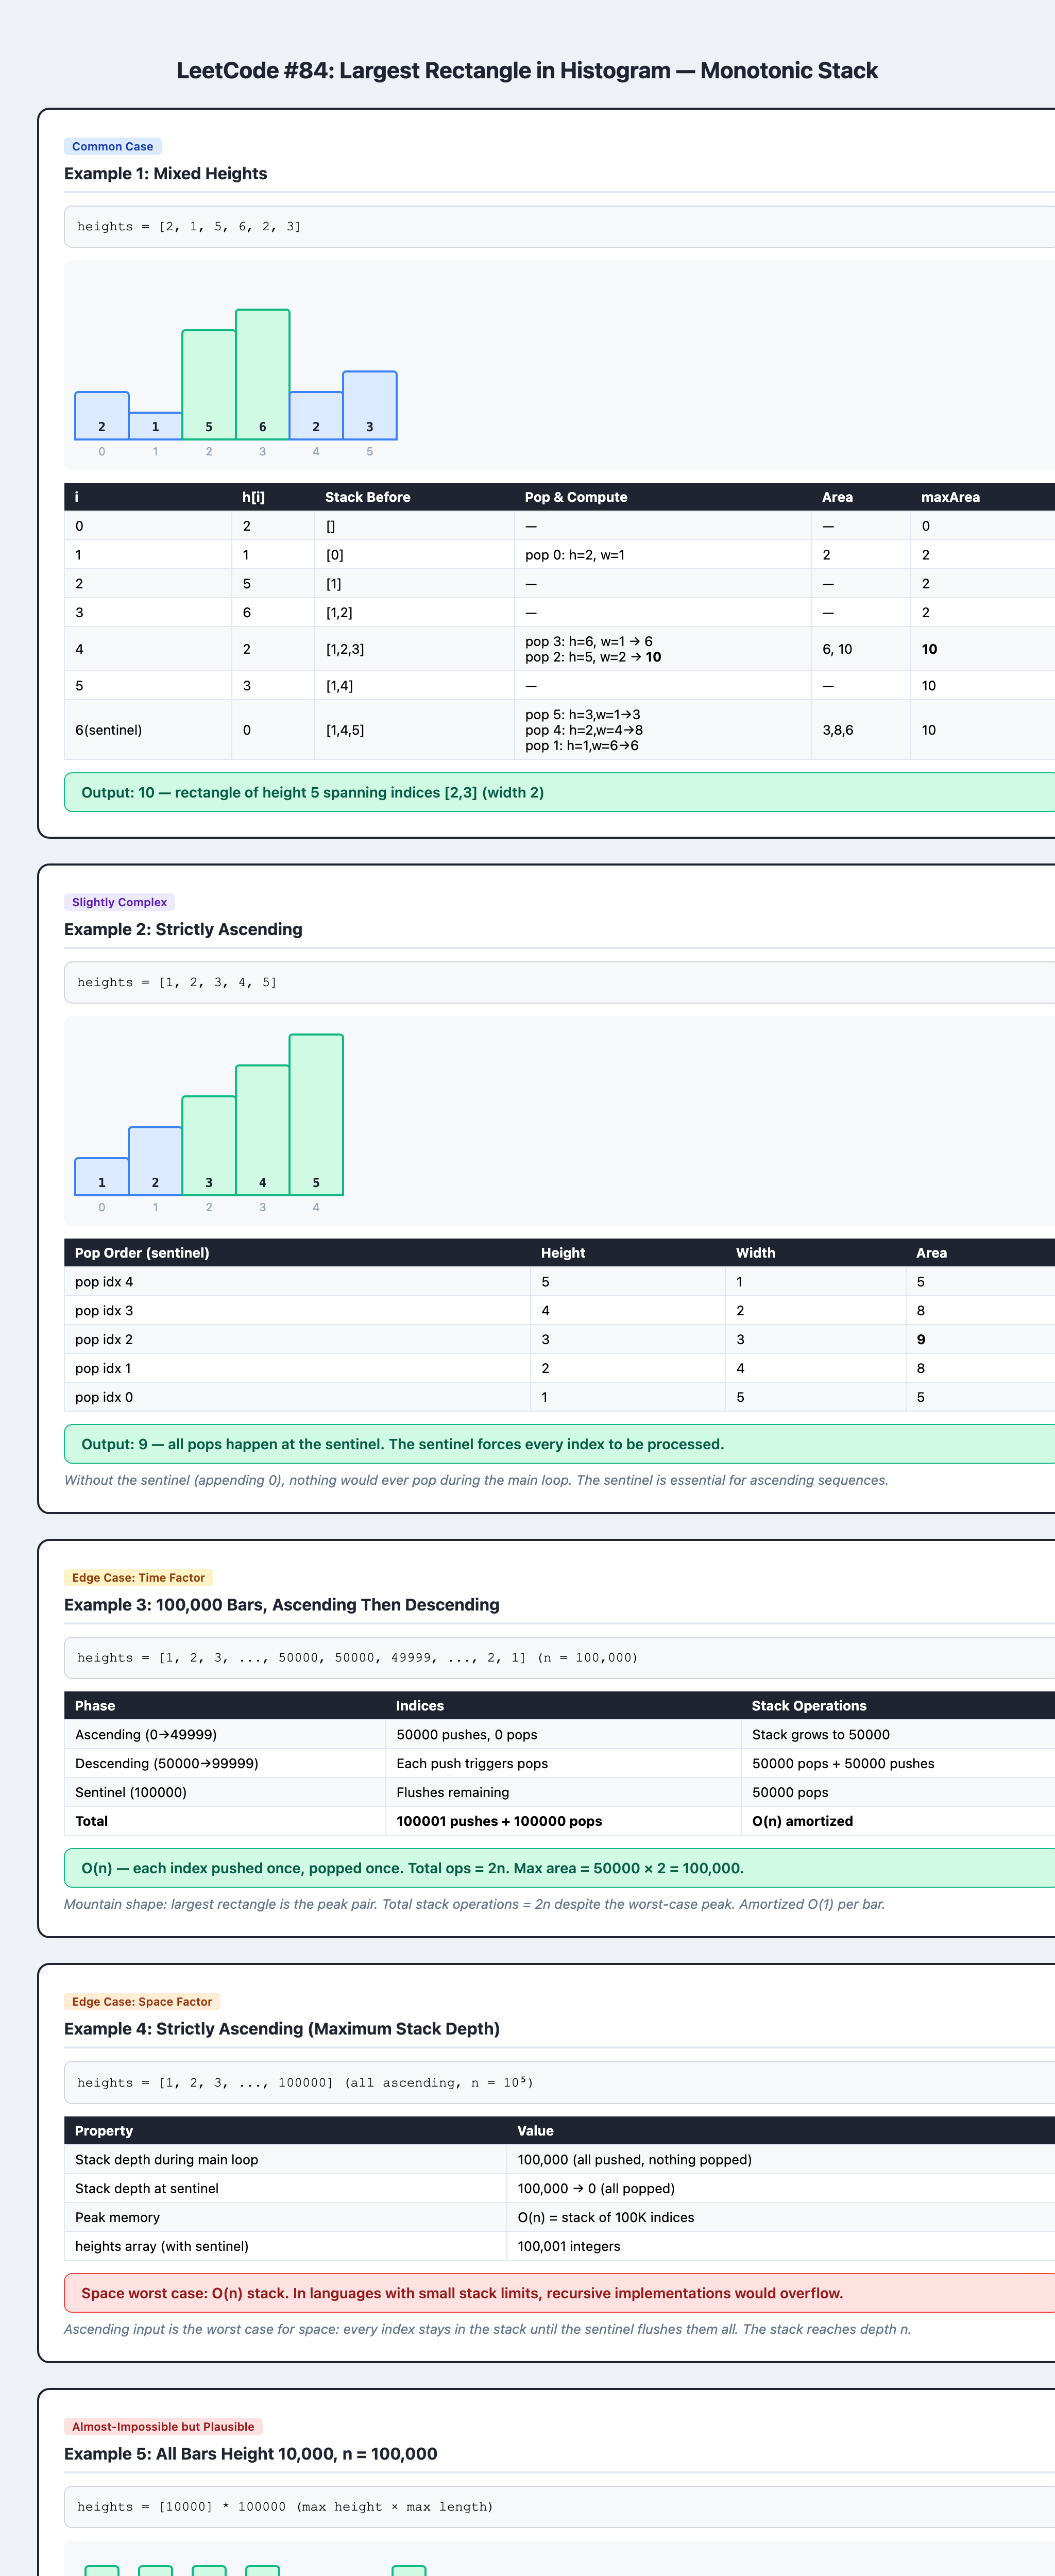